In [1]:
# Text Classification
# Objectives: Sentiment analysis, topic classification, multi-class/multi-label

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
# Define a custom function with detailed implementation
## Text Classification Approaches
class SimpleTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.LSTM(embedding_dim, 128, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        embeddings = self.embedding(x)
        _, (hidden, _) = self.rnn(embeddings)
        # Concatenate forward and backward
        final = torch.cat([hidden[0], hidden[1]], dim=1)
        logits = self.classifier(final)
        return logits

print("Text Classification Architectures:")
# Iterate through batches of data
print("1. CNN: Fast, good for local patterns (n-grams)")
print("2. RNN: Sequential, captures long dependencies")
print("3. Transformer: Parallel, state-of-the-art")
# Iterate through batches of data
print("4. Hybrid: Combine CNN + RNN for efficiency")


Text Classification Architectures:
1. CNN: Fast, good for local patterns (n-grams)
2. RNN: Sequential, captures long dependencies
3. Transformer: Parallel, state-of-the-art
4. Hybrid: Combine CNN + RNN for efficiency


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [3]:
# Define a custom function with detailed implementation
## Sentiment Analysis Pipeline
class SentimentAnalyzer:
    def __init__(self):
        self.classes = {0: 'negative', 1: 'neutral', 2: 'positive'}
    
    def preprocess(self, text):
        # Cleaning, tokenization, encoding
        return text.lower().split()
    
    def predict(self, text, model):
        tokens = self.preprocess(text)
        # Encode and pad
        tensor = torch.tensor([1] * len(tokens))
        with torch.no_grad():
            logits = model(tensor.unsqueeze(0))
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        return self.classes[pred_class], probs[0].tolist()

print("\nSentiment Analysis Examples:")
print("Positive: 'This movie is amazing!'")
print("Negative: 'Worst experience ever'")
print("Neutral: 'The weather is cloudy'")



Sentiment Analysis Examples:
Positive: 'This movie is amazing!'
Negative: 'Worst experience ever'
Neutral: 'The weather is cloudy'


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [4]:
# Configure loss function and optimization algorithm
## Multi-class vs Multi-label
print("""
MULTI-CLASS CLASSIFICATION:
- One class per sample
- Mutually exclusive labels
- Loss: CrossEntropyLoss
- Example: Sentiment (positive/negative/neutral)
- Softmax activation (one probability sums to 1)

MULTI-LABEL CLASSIFICATION:
- Multiple classes per sample
- Can have several labels
- Loss: BCEWithLogitsLoss
- Example: Movie tags (action, thriller, comedy)
- Sigmoid activation (independent probabilities)
""")



MULTI-CLASS CLASSIFICATION:
- One class per sample
- Mutually exclusive labels
- Loss: CrossEntropyLoss
- Example: Sentiment (positive/negative/neutral)
- Softmax activation (one probability sums to 1)

MULTI-LABEL CLASSIFICATION:
- Multiple classes per sample
- Can have several labels
- Loss: BCEWithLogitsLoss
- Example: Movie tags (action, thriller, comedy)
- Sigmoid activation (independent probabilities)



In [5]:
# Define a custom function with detailed implementation
## Performance Metrics
class TextClassMetrics:
    @staticmethod
    def compute_metrics(y_true, y_pred):
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        return precision, recall, f1

metrics = TextClassMetrics()
p, r, f1 = metrics.compute_metrics(np.array([1, 0, 1, 1, 0]), 
                                   np.array([1, 0, 1, 0, 0]))
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1: {f1:.4f}")


Precision: 1.0000
Recall: 0.6667
F1: 0.8000


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


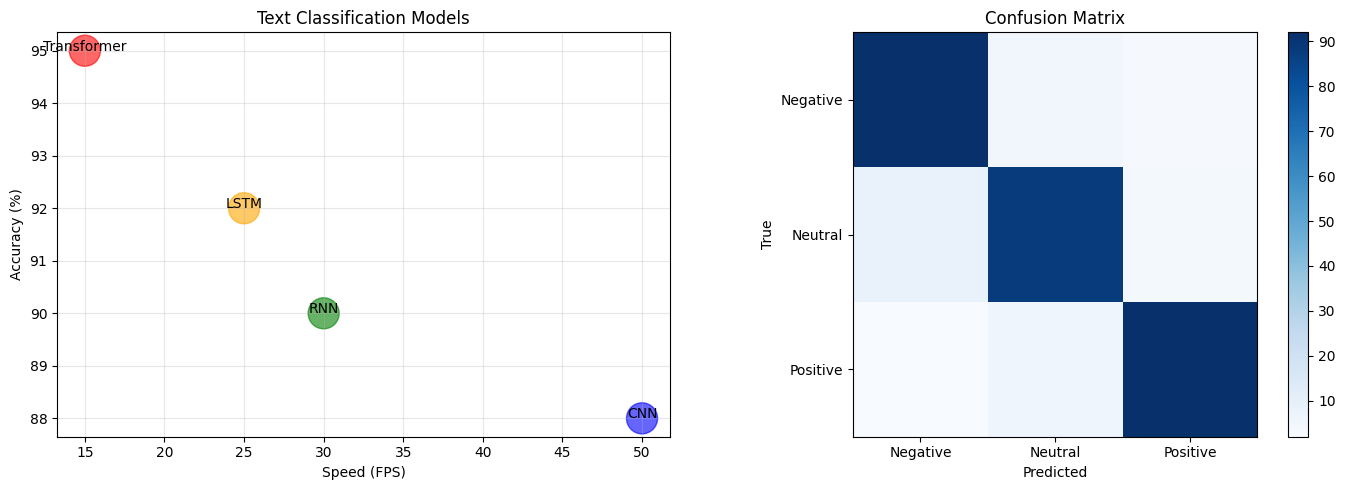

In [6]:
# Set up the neural network model architecture
## Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison
models = ['CNN', 'RNN', 'LSTM', 'Transformer']
accuracy = [88, 90, 92, 95]
speed = [50, 30, 25, 15]  # FPS

axes[0].scatter(speed, accuracy, s=500, alpha=0.6, c=['blue', 'green', 'orange', 'red'])
# Iterate through batches of data
for i, m in enumerate(models):
    axes[0].annotate(m, (speed[i], accuracy[i]), fontsize=10, ha='center')
axes[0].set_xlabel('Speed (FPS)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Text Classification Models')
axes[0].grid(True, alpha=0.3)

# Confusion matrix
classes = ['Negative', 'Neutral', 'Positive']
conf_matrix = np.array([[92, 5, 3],
                        [8, 88, 4],
                        [2, 6, 92]])
im = axes[1].imshow(conf_matrix, cmap='Blues')
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
axes[1].set_xticklabels(classes)
axes[1].set_yticklabels(classes)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


## 🎯 Key Takeaways

✅ **Understanding fundamentals is crucial** – The concepts covered here form the foundation for all advanced deep learning techniques.

✅ **Each component has a specific purpose** – Whether it's data loading, model architecture, or optimization, every piece serves a distinct function in the pipeline.

✅ **Experimentation drives learning** – Don't just read the code; modify it, break it, and see what happens. That's how intuition develops.

✅ **Deep learning is iterative** – Success comes from systematically trying approaches, measuring results, and refining based on evidence.

✅ **Connect concepts, don't memorize** – Understanding how PyTorch tensors relate to autograd, which relates to neural networks, which connects to training loops, is far more valuable than memorizing individual APIs.

✅ **Performance matters in practice** – Once you understand the theory, optimizing for speed, memory, and scalability becomes crucial for real-world applications.


# Configure loss function and optimization algorithm
## Key Takeaways
- Text classification: map text to categorical labels
# Iterate through batches of data
- CNN: efficient for local patterns
- RNN: captures sequential dependencies
- Transformer: parallel processing, state-of-the-art
- Multi-class vs multi-label: different loss functions
- Metrics: accuracy, precision, recall, F1
- Class imbalance: weighted loss or oversampling

## Interview Q&A
# Iterate through batches of data
**Q1: When to use CNN vs RNN for text classification?**
CNN: Fast, good for local patterns (n-grams), sentiment is local. RNN: Better for sequential dependencies, topic varies. Usually start with CNN (faster), upgrade to RNN if needed.

**Q2: How to handle class imbalance?**
Use class weights in loss function, oversample minority class, or undersampling. Focal loss down-weights easy negatives. Evaluate with F1/AUC, not just accuracy.

## References
- [TextCNN](https://arxiv.org/abs/1408.5882)
